
🏀 SPORTS VECTOR ANALYTICS - PLAYER PROFILER 🏀

Available players: LeBron James, Kevin Durant, Stephen Curry, Giannis Antetokounmpo, Nikola Jokic, Luka Doncic, Joel Embiid, Jayson Tatum

               📊 DEMO: Analyzing LeBron James               
------------------------------------------------------------

Top 3 players similar to LeBron James:
  1. Kevin Durant: 0.9984
  2. Luka Doncic: 0.9981
  3. Giannis Antetokounmpo: 0.9955

🏆 Most balanced player: Luka Doncic


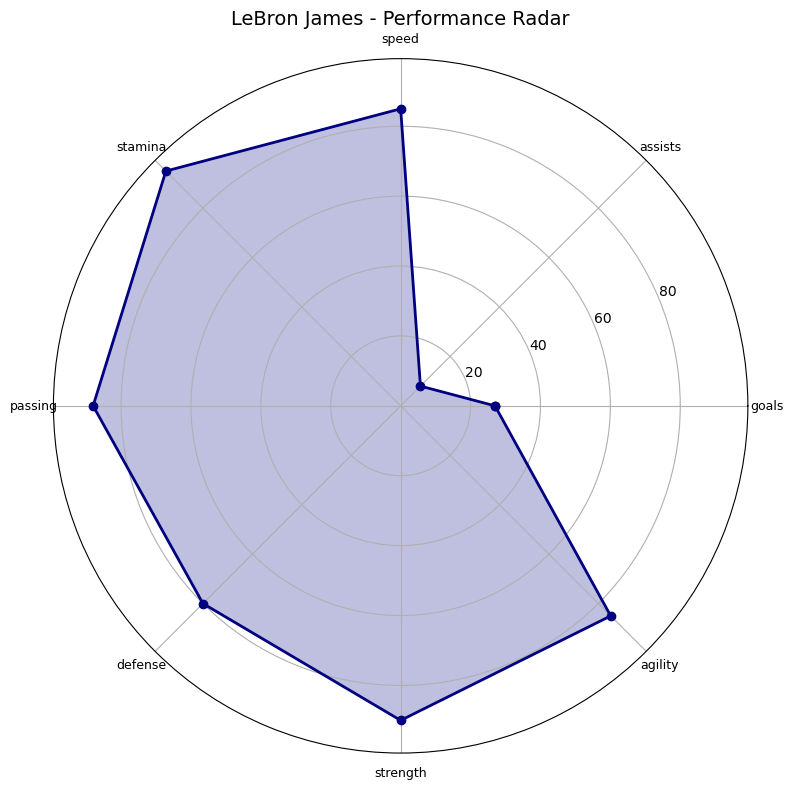

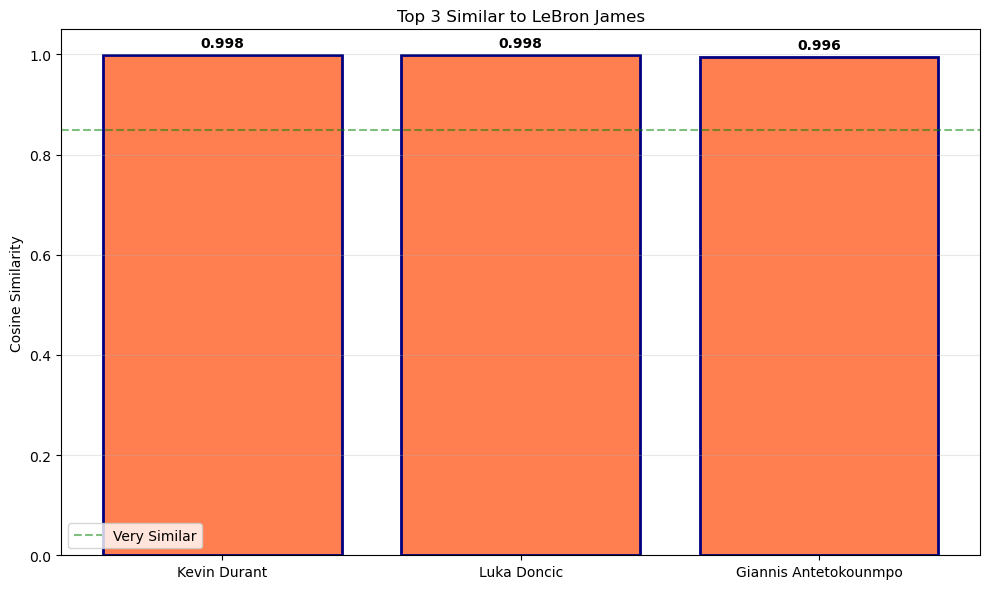

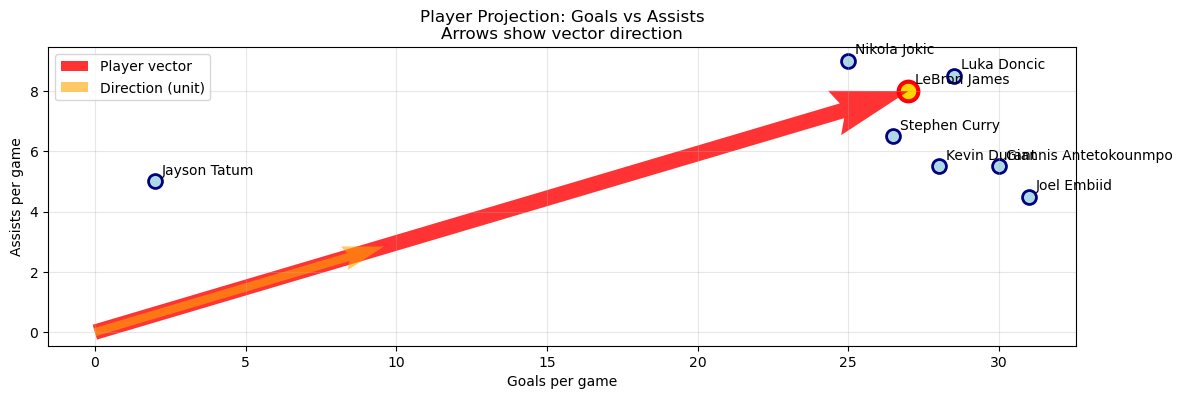


----------------------------------------
OPTIONS:
  1. Find similar players
  2. Show radar chart
  3. Show 2D projection
  4. Find most balanced player
  5. Exit



Choice (1-5):  2
Player name:  Jayson Tatum


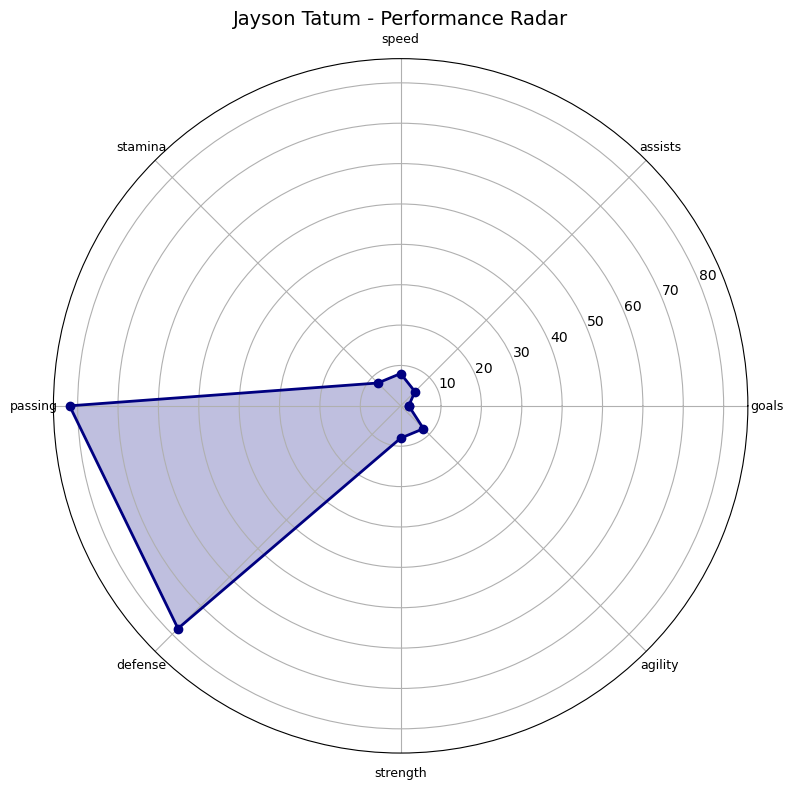


----------------------------------------
OPTIONS:
  1. Find similar players
  2. Show radar chart
  3. Show 2D projection
  4. Find most balanced player
  5. Exit


In [ ]:
"""
SPORTS VECTOR ANALYTICS - Player Performance Profiler
Linear Algebra for Deep Learning - Project 1
Author: Fonyuy Gita
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================
# PART 1: VECTOR MATH FUNCTIONS (from scratch)
# ============================================

def dot_product(v1, v2):
    """v1·v2 = sum of products of matching elements"""
    return sum(v1[i] * v2[i] for i in range(len(v1)))

def l2_norm(v):
    """||v|| = sqrt(sum of squares) - vector length"""
    return np.sqrt(sum(x**2 for x in v))

def cosine_similarity(v1, v2):
    """cos(θ) = (v1·v2)/(||v1||×||v2||) - measures direction similarity"""
    dot = dot_product(v1, v2)
    norm1, norm2 = l2_norm(v1), l2_norm(v2)
    return dot / (norm1 * norm2) if norm1 * norm2 != 0 else 0

def unit_vector(v):
    """v̂ = v/||v|| - preserves direction, length becomes 1"""
    norm = l2_norm(v)
    return np.array([x / norm for x in v]) if norm != 0 else v

# ============================================
# PART 2: PLAYER DATASET (8 stats per player)
# ============================================

stats_names = ['goals', 'assists', 'speed', 'stamina', 'passing', 'defense', 'strength', 'agility']

players = {
    'LeBron James': np.array([27.0, 8.0, 85, 95, 88, 80, 90, 85]),
    'Kevin Durant': np.array([28.0, 5.5, 82, 88, 86, 75, 78, 88]),
    'Stephen Curry': np.array([26.5, 6.5, 88, 90, 96, 65, 70, 92]),
    'Giannis Antetokounmpo': np.array([30.0, 5.5, 92, 94, 72, 85, 98, 82]),
    'Nikola Jokic': np.array([25.0, 9.0, 65, 88, 94, 70, 88, 70]),
    'Luka Doncic': np.array([28.5, 8.5, 75, 85, 90, 68, 85, 78]),
    'Joel Embiid': np.array([31.0, 4.5, 70, 80, 70, 85, 95, 68]),
    'Jayson Tatum': np.array([2.0, 5.0, 8, 8, 82, 78, 8, 8])
}

# ============================================
# PART 3: PLAYER COMPARISON FUNCTIONS
# ============================================

def find_similar_players(player_name, players_dict, top_n=3):
    """Return top_n players most similar to given player using cosine similarity"""
    if player_name not in players_dict:
        print(f"Player '{player_name}' not found!")
        return []
    
    target = players_dict[player_name]
    similarities = []
    
    for name, stats in players_dict.items():
        if name != player_name:
            sim = cosine_similarity(target, stats)
            similarities.append((name, sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

def find_most_balanced_player(players_dict):
    """Player whose stats are closest to average (smallest L2 distance from mean)"""
    all_stats = np.array(list(players_dict.values()))
    mean_stats = np.mean(all_stats, axis=0)
    
    best_player = None
    best_score = float('inf')
    
    for name, stats in players_dict.items():
        score = l2_norm(stats - mean_stats)
        if score < best_score:
            best_score = score
            best_player = name
    
    return best_player, best_score

# ============================================
# PART 4: VISUALIZATIONS
# ============================================

def plot_radar_chart(player_name, players_dict):
    """Create radar/spider chart showing all stats for one player"""
    stats = players_dict[player_name]
    angles = np.linspace(0, 2*np.pi, len(stats_names), endpoint=False).tolist()
    
    # Close the polygon
    stats_plot = np.append(stats, stats[0])
    angles_plot = np.append(angles, angles[0])
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    ax.plot(angles_plot, stats_plot, 'o-', linewidth=2, color='navy')
    ax.fill(angles_plot, stats_plot, alpha=0.25, color='navy')
    ax.set_xticks(angles)
    ax.set_xticklabels(stats_names, size=9)
    ax.set_title(f"{player_name} - Performance Radar", size=14)
    plt.tight_layout()
    plt.show()

def plot_similarity_bar_chart(player_name, similar_players):
    """Bar chart showing similarity scores of top matches"""
    names = [p[0] for p in similar_players]
    scores = [p[1] for p in similar_players]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(names, scores, color='coral', edgecolor='navy', linewidth=2)
    
    # Add score labels on bars
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'Top {len(similar_players)} Similar to {player_name}')
    ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Very Similar')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_2d_projection(players_dict, highlighted_player=None):
    """2D scatter plot using goals (x) and assists (y) with vector arrows"""
    goals = [stats[0] for stats in players_dict.values()]
    assists = [stats[1] for stats in players_dict.values()]
    names = list(players_dict.keys())
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(goals, assists, s=100, c='lightblue', edgecolor='navy', linewidth=2)
    
    # Add labels
    for i, name in enumerate(names):
        ax.annotate(name, (goals[i], assists[i]), xytext=(5, 5), textcoords='offset points')
    
    # Highlight and add vector arrow for specific player
    if highlighted_player and highlighted_player in players_dict:
        idx = names.index(highlighted_player)
        ax.scatter([goals[idx]], [assists[idx]], s=200, c='gold', edgecolor='red', linewidth=3)
        
        # Draw vector from origin to player
        ax.quiver(0, 0, goals[idx], assists[idx], angles='xy', scale_units='xy',
                 scale=1, color='red', alpha=0.8, width=0.015, label='Player vector')
        
        # Draw unit vector (normalized direction)
        unit = np.array([goals[idx], assists[idx]])
        unit = unit / np.linalg.norm(unit) * 10  # Scale for visibility
        ax.quiver(0, 0, unit[0], unit[1], angles='xy', scale_units='xy',
                 scale=1, color='orange', alpha=0.6, width=0.008, label='Direction (unit)')
    
    ax.set_xlabel('Goals per game')
    ax.set_ylabel('Assists per game')
    ax.set_title('Player Projection: Goals vs Assists\nArrows show vector direction')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# ============================================
# PART 5: CLI INTERFACE
# ============================================

def main():
    """Main program with interactive CLI"""
    print("\n" + "="*60)
    print("🏀 SPORTS VECTOR ANALYTICS - PLAYER PROFILER 🏀")
    print("="*60)
    print("\nAvailable players:", ', '.join(players.keys()))
    
    # Demo: Show LeBron James analysis
    print("\n" + "📊 DEMO: Analyzing LeBron James".center(60))
    print("-"*60)
    
    similar = find_similar_players('LeBron James', players)
    print("\nTop 3 players similar to LeBron James:")
    for i, (name, score) in enumerate(similar, 1):
        print(f"  {i}. {name}: {score:.4f}")
    
    best_player, score = find_most_balanced_player(players)
    print(f"\n🏆 Most balanced player: {best_player}")
    
    # Show visualizations
    plot_radar_chart('LeBron James', players)
    plot_similarity_bar_chart('LeBron James', similar)
    plot_2d_projection(players, highlighted_player='LeBron James')
    
    # Interactive CLI
    while True:
        print("\n" + "-"*40)
        print("OPTIONS:")
        print("  1. Find similar players")
        print("  2. Show radar chart")
        print("  3. Show 2D projection")
        print("  4. Find most balanced player")
        print("  5. Exit")
        
        choice = input("\nChoice (1-5): ").strip()
        
        if choice == '1':
            name = input("Player name: ").strip()
            if name in players:
                similar = find_similar_players(name, players)
                print(f"\nTop {len(similar)} similar to {name}:")
                for i, (n, s) in enumerate(similar, 1):
                    print(f"  {i}. {n}: {s:.4f}")
                plot_similarity_bar_chart(name, similar)
            else:
                print(f"Player '{name}' not found!")
        
        elif choice == '2':
            name = input("Player name: ").strip()
            if name in players:
                plot_radar_chart(name, players)
            else:
                print(f"Player '{name}' not found!")
        
        elif choice == '3':
            name = input("Player to highlight (Enter for all): ").strip()
            if name and name in players:
                plot_2d_projection(players, highlighted_player=name)
            else:
                plot_2d_projection(players)
        
        elif choice == '4':
            best, _ = find_most_balanced_player(players)
            print(f"\n🏆 Most balanced player: {best}")
            print("(Closest to league average in all stats)")
        
        elif choice == '5':
            print("\nThank you for using Sports Vector Analytics! 🏀")
            break
        
        else:
            print("Invalid choice!")

# ============================================
# RUN THE PROGRAM
# ============================================

if __name__ == "__main__":
    main()